# Previous Material: Not Assigned

This notebook uses another textbook's chapter numbering. It is retained for review, not assigned reading for the current course. Its chapter, week, and examination labels are historical and do not define current requirements. Use the current course syllabus and its first-meeting notebook links.


# Chapter 17: Transactions


## Core Question

When one business operation uses several data changes and several transactions run at the
same time, how can we judge whether the overall result is complete, serializable, and
recoverable?


## Connection to Other Chapters

Chapters 14-16 explained execution of one query. This chapter studies groups of queries
and updates that may interleave or fail. Chapter 18 introduces locks and deadlock; Chapter
19 introduces log-based recovery.


## Teaching Summary

| Topic | Worked example and practice | Evidence to retain |
|---|---|---|
| ACID and transaction states | Account transfer with commit or rollback | State sequence and final balances |
| Conflicts and serializability | Interleaved read/write schedule | Prediction, precedence graph, and cycle check |
| Recoverability | Read-from and commit order | Separate property decisions |
| Isolation and SQL activity | Concurrent-seat scenario and SQLite lab | Observed result and model limitation |


## Prerequisites

You should be able to read basic SQL, keys, and constraints and distinguish a schema from
its current data.


## Learning Objectives

After completing this chapter, you should be able to:

1. Explain atomicity, consistency, isolation, and durability through one transaction.
2. Identify active, partially committed, failed, aborted, and committed states.
3. Identify conflicting operations in a small schedule.
4. Build a precedence graph and test it for a cycle.
5. Distinguish serializability, recoverability, and cascadelessness.
6. Recognize dirty read, nonrepeatable read, and phantom scenarios.
7. Execute and verify basic `COMMIT` and `ROLLBACK` behavior.

Locking, timestamp ordering, and multiversion implementation are bridges to Chapter 18,
not major operations in this chapter.


## 1. Transaction and ACID

A transaction is one execution unit that may read and update several data items. A bank
transfer from A to B can be represented as:

```text
read(A)
A := A - 50
write(A)
read(B)
B := B + 50
write(B)
```

With A=1000 and B=2000, a correct final state is A=950 and B=2050, with total 3000.

| Property | Meaning in this example |
|---|---|
| Atomicity | Both account changes occur or neither occurs |
| Consistency | A correct transaction preserves stated rules such as nonnegative balances and total funds |
| Isolation | Concurrent transactions do not treat a partial transfer as a final state |
| Durability | A committed transfer remains after a system failure |

The DBMS cannot make incorrect application logic correct merely by committing it.
Durability also requires recovery evidence; reopening a file after a normal close is not
a crash-recovery test.


### Running the Small Examples

Run this setup cell once. Each small SQL example starts from its displayed input tables in a fresh in-memory SQLite database and closes it afterward. The table definitions and SQL are supplied; Python helper syntax is not an additional learning requirement. Read and predict before running each example. The larger chapter lab remains available later in this notebook. The instructor will select variations for class practice; the additional examples are not separate required assignments.


In [1]:
import sqlite3


def run_small_example(tables, statements):
    """Start with the displayed input again each time; keep no database file."""
    db = sqlite3.connect(":memory:", isolation_level=None)
    db.execute("PRAGMA foreign_keys = ON")
    try:
        for name, definition, rows in tables:
            db.execute(f"CREATE TABLE {name} ({definition})")
            if rows:
                marks = ", ".join("?" for _ in rows[0])
                db.executemany(f"INSERT INTO {name} VALUES ({marks})", rows)
        for label, sql in statements:
            print(label)
            try:
                cursor = db.execute(sql)
                if cursor.description:
                    print(" | ".join(column[0] for column in cursor.description))
                    rows = cursor.fetchall()
                    for row in rows:
                        print(" | ".join("NULL" if value is None else str(value) for value in row))
                    if not rows:
                        print("(no rows)")
                else:
                    print("Statement completed.")
            except sqlite3.IntegrityError:
                print("IntegrityError: the statement was rejected.")
            print()
    finally:
        db.close()


### Keep both account changes or neither

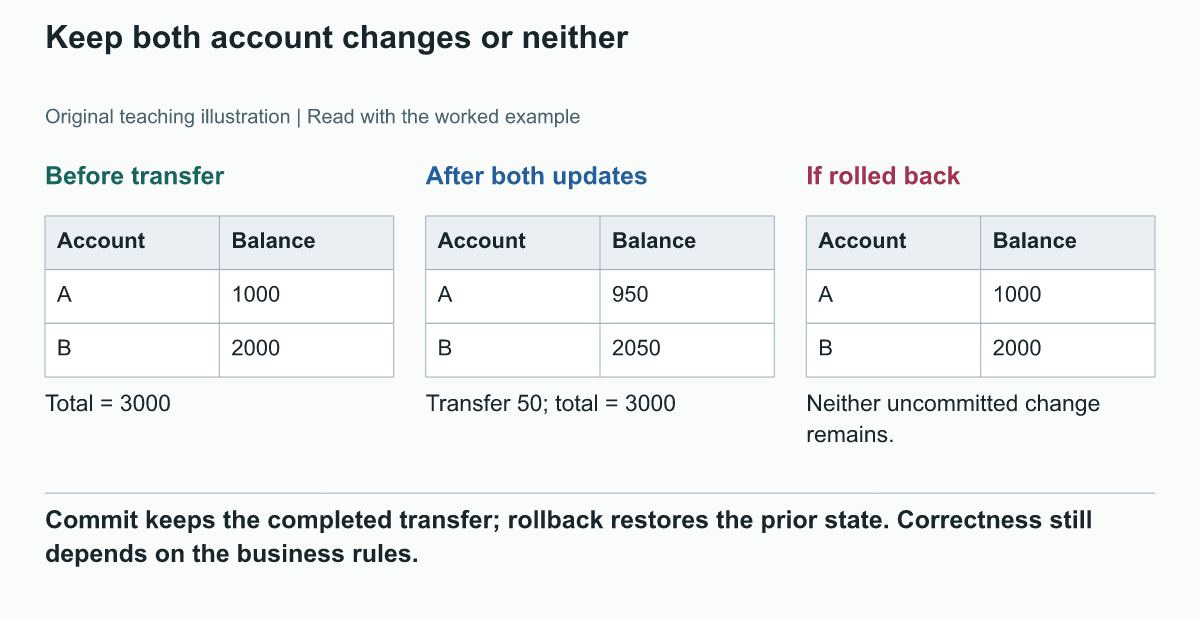

Commit keeps the completed transfer; rollback restores the prior state. Correctness still depends on the business rules.


### Small Example: Committing the wrong calculation does not fix it

Atomicity groups changes, but consistency still depends on correct rules and application logic. A transaction can commit successfully while a missing business check allows a wrong total.

The following data are artificial teaching inputs, not student records.

**Input: account**

| id | balance |
| --- | --- |
| A | 100 |
| B | 50 |

**Predict before checking.** If 10 is deducted from A but only 5 is added to B, does the nonnegative-balance CHECK detect the missing money?


In [2]:
tables = [('account',
  'id TEXT NOT NULL PRIMARY KEY, balance INTEGER CHECK(balance>=0)',
  [['A', 100], ['B', 50]])]
statements = [
    ('Start', """
BEGIN
"""),
    ('Debit', """
UPDATE account SET balance=balance-10 WHERE id='A'
"""),
    ('Incorrect credit', """
UPDATE account SET balance=balance+5 WHERE id='B'
"""),
    ('Commit', """
COMMIT
"""),
    ('Balances', """
SELECT * FROM account ORDER BY id
"""),
    ('Total', """
SELECT SUM(balance) AS total FROM account
"""),
]
run_small_example(tables, statements)


Start
Statement completed.

Debit
Statement completed.

Incorrect credit
Statement completed.

Commit
Statement completed.

Balances
id | balance
A | 90
B | 55

Total
total
145



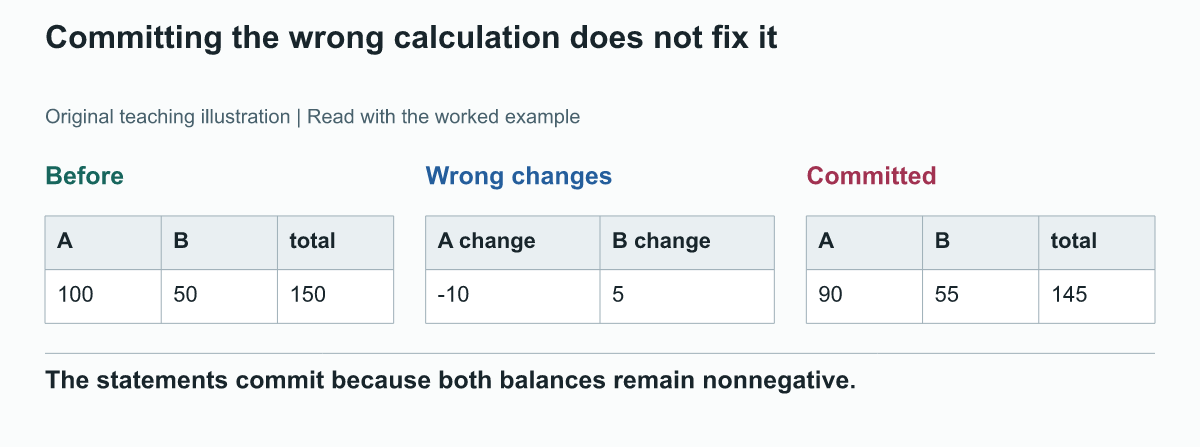


**Read the result.** The statements commit because both balances remain nonnegative. The total falls from 150 to 145, violating the stated transfer rule. A successful commit is not proof that the business calculation is correct.

**Try a change.** Correct the credit amount and check both individual balances and the unchanged total.

**Check your reasoning.** A total check and a row-level range constraint test different properties.

When this variation is assigned, retain your prediction, result, and correction or explanation.


### Practice

Match each case to its main ACID concern and explain the data effect:

1. One of two concurrent edits disappears.
2. A reported successful order is missing after restart.
3. Order detail exists without its required order header.
4. Inventory becomes negative because no rule prevents it.

The main answers are isolation, durability, atomicity, and consistency.


## 2. Transaction States

```text
active -> partially committed -> committed
   |               |
   +-----> failed <-+
             |
             v
          aborted -> terminated
             |
             +-----> active when a safe retry is allowed
```

- **Active:** execution is in progress.
- **Partially committed:** the last statement finished, but durable commit is not yet
  established.
- **Committed:** the system accepts the transaction as successfully completed.
- **Failed:** execution cannot continue normally.
- **Aborted:** effects have been removed.

A deadlock victim may be safe to retry. Invalid SQL, a permanent constraint violation,
or incorrect application logic usually requires correction rather than identical retry.
Statement-error behavior differs among DBMS products and drivers.


### Small Example: The last statement is not yet a durable commit

A transaction may finish its last statement before its commit is durably established. That partially committed point still has a failure path. An aborted transaction has had its effects removed.

The following data are artificial teaching inputs, not student records.

**Input: events**

| step | event |
| --- | --- |
| 1 | last UPDATE finishes |
| 2 | commit not yet durable |
| 3 | system fails |

**Predict before checking.** Does finishing the last UPDATE justify calling this transaction committed? Which state follows failure and removal of its effects?


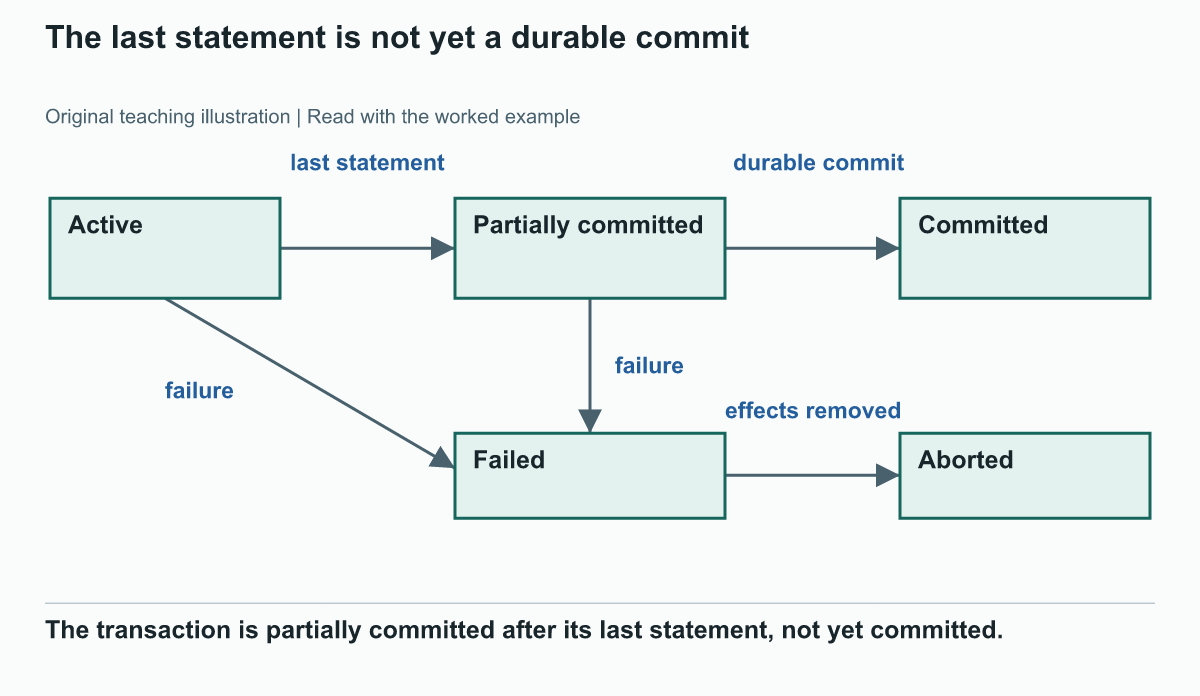


**Read the result.** The transaction is partially committed after its last statement, not yet committed. In the stated failure path it becomes failed, then aborted after its effects are removed. Safe retry requires a separate decision.

**Try a change.** Draw the successful alternative through durable commit, then the failed alternative without assuming that identical retry is always appropriate.

**Check your reasoning.** Place the durable-commit event explicitly. Do not merge failed, aborted, and committed into one state.

When this variation is assigned, retain your prediction, result, and correction or explanation.


### Practice

Write a state path for a successful commit, a deadlock victim that is safely retried, and
a failure after the last statement but before commit becomes durable.


## 3. Schedules and Conflicts

A **schedule** records the order of important operations from several transactions while
preserving each transaction's own operation order. A serial schedule completes one
transaction before the next. A serializable schedule may interleave operations but has an
effect equivalent to a serial order.

Two operations conflict when they:

1. belong to different transactions;
2. access the same data item; and
3. include at least one write.

Read-read does not conflict. Read-write, write-read, and write-write on the same item do.


### A precedence graph records conflicting operation order

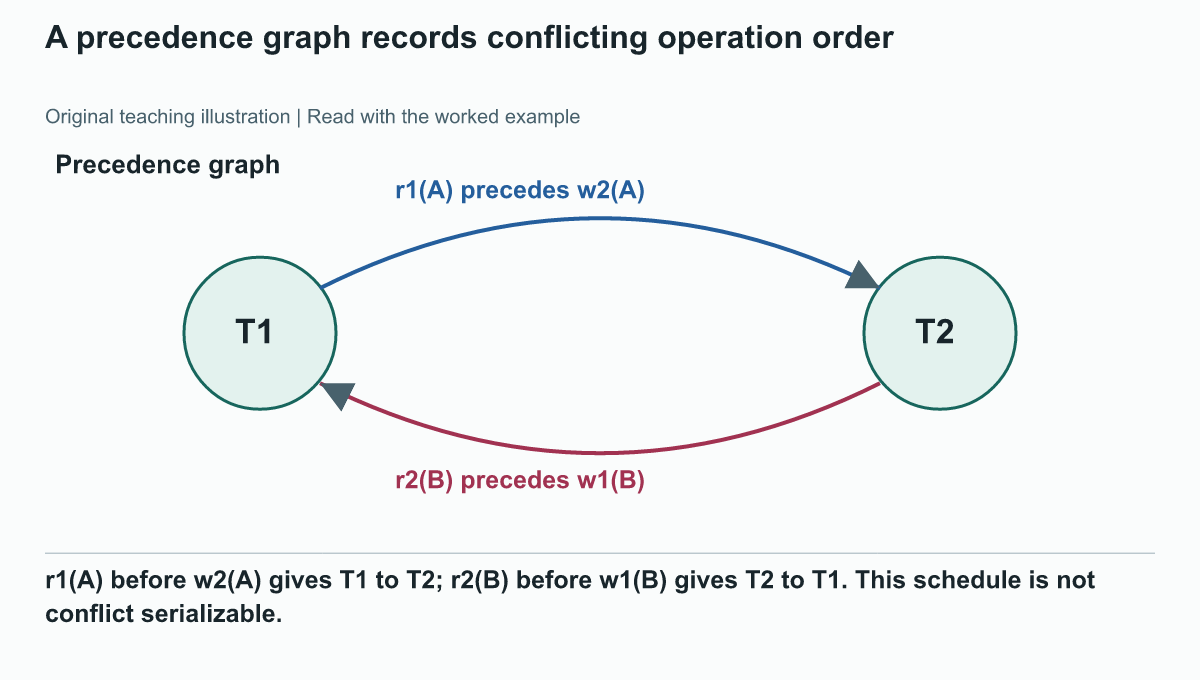

r1(A) before w2(A) gives T1 to T2; r2(B) before w1(B) gives T2 to T1. This schedule is not conflict serializable.


### Small Example: Check all three conflict conditions

Two operations conflict only when different transactions access the same item and at least one writes. Operation order then determines the precedence edge. Similar-looking letters on different items do not conflict.

The following data are artificial teaching inputs, not student records.

**Input: pairs**

| first | second |
| --- | --- |
| r1(A) | r2(A) |
| r1(A) | w2(A) |
| w1(A) | w2(B) |
| w1(A) | w2(A) |

**Predict before checking.** Which pairs create T1 -> T2 when the first operation precedes the second?


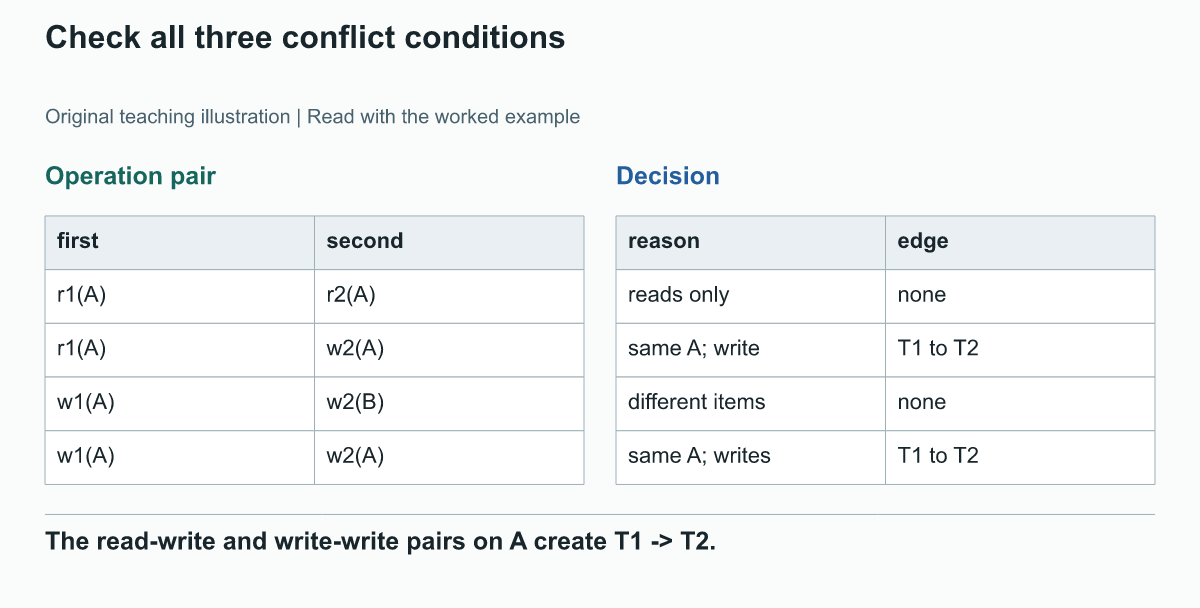


**Read the result.** The read-write and write-write pairs on A create T1 -> T2. The read-read pair has no write, and the A/B pair uses different items. Neither of those two pairs creates a conflict edge.

**Try a change.** Reverse the operation order of the read-write pair, then place both directions in one schedule and check for a cycle.

**Check your reasoning.** For every edge cite the two operations, shared item, and earlier-to-later direction.

When this variation is assigned, retain your prediction, result, and correction or explanation.


### Acyclic Example

```text
r1(A), w1(A), r2(A), r2(B), w2(B)
```

`w1(A)` precedes `r2(A)`, giving edge `T1 -> T2`. The graph has no cycle, so the schedule
is conflict serializable with order T1, T2.


### Cyclic Example

```text
r1(A), r2(B), w1(B), w2(A)
```

The B conflict gives `T2 -> T1`; the A conflict gives `T1 -> T2`. The cycle means the
schedule is not conflict serializable.


### Practice

Analyze:

```text
r1(A), r2(A), w2(A), r1(B), w1(B), c2, c1
```

The A conflict gives `T1 -> T2`. There is no reverse conflict edge, so the graph is
acyclic and T1, T2 is a serial order. Commit order need not equal serialization order.


## 4. Recoverability and Cascadelessness

Serializability concerns the interleaved result. Recoverability concerns commit order
after one transaction reads another transaction's write.

If Tj reads a value written by Ti, a recoverable schedule requires `commit(Ti)` before
`commit(Tj)`. A cascadeless schedule requires the stronger order `commit(Ti)` before the
dependent read by Tj.

```text
S1: w1(A), r2(A), c2, a1
S2: w1(A), r2(A), c1, c2
S3: w1(A), c1, r2(A), c2
```

- S1 is nonrecoverable.
- S2 is recoverable but not cascadeless.
- S3 is cascadeless and therefore recoverable.

Practice: move only `r2(X)` in `w1(X), r2(X), c1, c2` to make the schedule cascadeless.
The result is `w1(X), c1, r2(X), c2`.


### Small Example: Move the writer's commit before the dependent read

When T2 reads a value written by T1, recoverability constrains their commits. Cascadelessness adds a stronger requirement: T1 must commit before T2 reads that value.

The following data are artificial teaching inputs, not student records.

**Input: events**

| position | event |
| --- | --- |
| 1 | w1(A) |
| 2 | r2(A) |
| 3 | c1 |
| 4 | c2 |

**Predict before checking.** Is the shown schedule recoverable? Is its dependent read already protected from a rollback of T1?


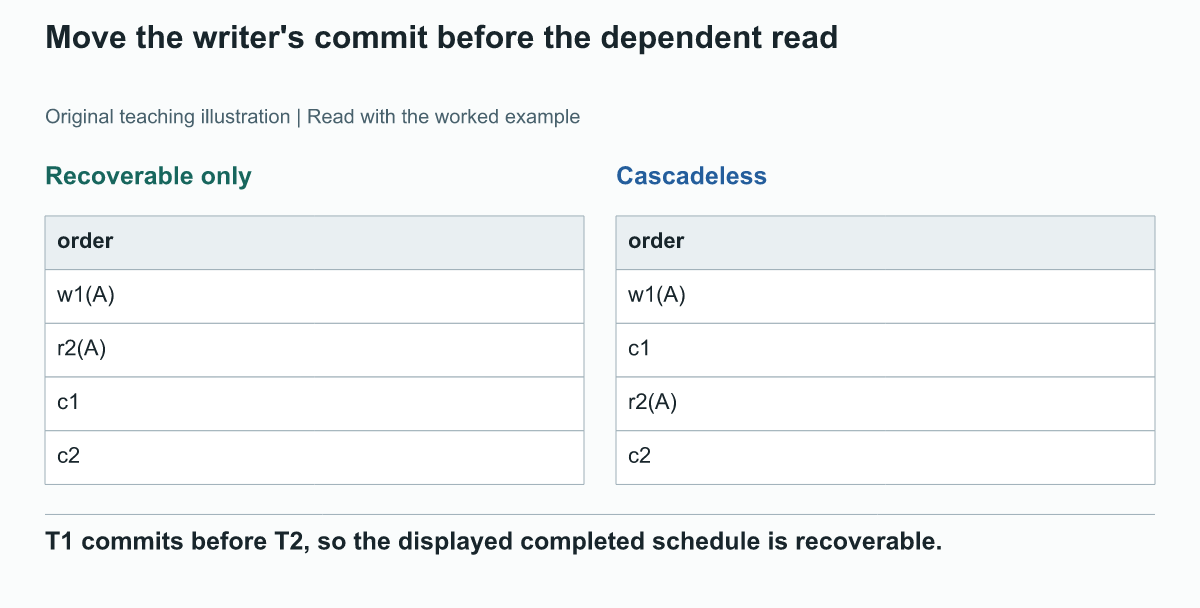


**Read the result.** T1 commits before T2, so the displayed completed schedule is recoverable. However, T2 read before T1 committed, so it is not cascadeless. Moving c1 before r2(A) gives the stronger order.

**Try a change.** Place c2 before c1 and explain why T2 could commit a result based on work that later aborts.

**Check your reasoning.** Identify the write-read dependency first, then compare the relevant event positions. Do not use the precedence graph as a substitute for commit-order analysis.

When this variation is assigned, retain your prediction, result, and correction or explanation.


## 5. Isolation Phenomena

- **Dirty read:** a transaction reads another transaction's uncommitted value, which may
  later be rolled back.
- **Nonrepeatable read:** the same row is read twice and a committed update changes its
  value between reads.
- **Phantom:** the same predicate query returns a different set because another
  transaction inserts, deletes, or updates a matching row.
- **Lost update:** one transaction's update overwrites another update based on an older
  value.


### Small Example: An existing value changes versus a new matching row appears

A nonrepeatable read changes a previously read row value. A phantom changes the set selected by a predicate. The following event trace is a conceptual concurrency scenario, not a live SQLite isolation test.

The following data are artificial teaching inputs, not student records.

**Input: initial**

| row | salary |
| --- | --- |
| I1 | 100 |
| I2 | 80 |

**Predict before checking.** T1 counts salaries above 90 and gets 1. If T2 inserts I3 with 110 and commits, how does a later visible repeat differ from rereading I1 after its salary is updated?


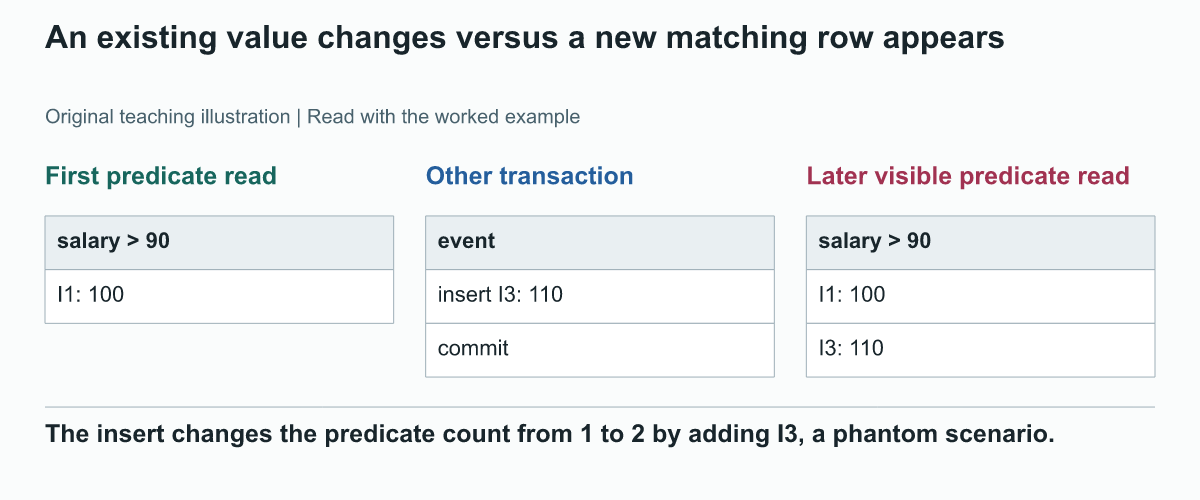


**Read the result.** The insert changes the predicate count from 1 to 2 by adding I3, a phantom scenario. Updating I1 from 100 to 120 changes an existing row value, a nonrepeatable-read scenario. Whether either becomes visible depends on the actual isolation behavior.

**Try a change.** Describe a dirty-read variant in which T2 has not committed and later rolls back. State exactly which value T1 used.

**Check your reasoning.** Separate uncommitted values, changes to existing rows, and changes to predicate membership. Do not claim a specific product permits them without a concurrent test.

When this variation is assigned, retain your prediction, result, and correction or explanation.


### Textbook Isolation-Level Model

| Level | Main promise and remaining risk |
|---|---|
| Serializable | Execution must satisfy a serializable result |
| Repeatable read | Committed row values repeat, but phantoms may remain |
| Read committed | No dirty read; repeated values and predicate sets may change |
| Read uncommitted | Dirty, nonrepeatable, and phantom reads may occur |

Product behavior can differ even when names match. Check official documentation and run
a concurrent multi-connection test before making a product claim.


### Phantom Example

T1 runs:

```sql
SELECT COUNT(*)
FROM instructor
WHERE salary > 90000;
```

T2 inserts a matching instructor and commits before T1 repeats the query. The result set
changes even though the new row was not part of T1's first read.


## 6. SQL Transaction Activity

The course SQLite lab uses:

```sql
BEGIN;
-- statements
COMMIT;

BEGIN;
-- statements
ROLLBACK;
```

Transaction-start syntax, autocommit, and isolation-setting syntax are product and driver
specific.


### Worked Result

The first lab transaction temporarily changes A to 950 and then rolls back, restoring
A=1000 and B=2000. The second changes both accounts and writes one transfer-log row before
commit. The final values are A=950, B=2050, total 3000, and one committed log row.


### Practice

Add checks that both accounts exist, the source has enough balance, and account changes
and log insertion commit or roll back together. Test both a successful transfer and an
insufficient-funds case. "No SQL error" is not sufficient evidence.


## 7. Schedule Analyzer

```powershell
Run the embedded schedule-analyzer cell below.
```

The program finds conflicts, builds a precedence graph, attempts a topological order, and
tracks the most recent preceding write for the supplied small schedules.

| Schedule | Conflict serializable | Recoverable | Cascadeless |
|---|---:|---:|---:|
| `acyclic` | Yes | Yes | Yes |
| `cycle` | No | Yes | Yes |
| `recoverable_but_not_cascadeless` | Yes | Yes | No |
| `nonrecoverable` | Yes | No | No |
| `cascadeless` | Yes | Yes | Yes |

The `cycle` example has no read-from dependency, so its recoverability checks pass even
though it is not serializable. These are different properties.

The analyzer is a teaching model. It does not implement predicate reads, versions,
conditional writes, or complete SQL semantics.


## Common Errors

1. Treating serial and serializable as synonyms.
2. Drawing a graph edge without checking different transactions, same item, and a write.
3. Calling every acyclic schedule recoverable.
4. Treating recoverable and cascadeless as the same property.
5. Treating commit as proof of correct business logic.
6. Treating repeatable read as protection from every phantom.
7. Assuming that snapshot isolation is automatically serializable.
8. Generalizing one SQLite connection to concurrent DBMS behavior.


## Discussion and Individual Evidence

Analyze two users who both read one remaining seat and then create separate orders. State
the initial operations, final state, and whether a legal serial order could produce it.

Retain ACID answers, one acyclic and one cyclic graph, recoverability decisions, isolation
examples, lab rollback/commit output, analyzer output, and one explicit model limitation.


## Chapter Summary

A transaction groups data operations under ACID expectations. A precedence graph tests
conflict serializability, while recoverability and cascadelessness inspect read-from and
commit order. Isolation levels permit different anomalies and must be verified in the
actual DBMS. Chapter 18 turns these requirements into lock and deadlock decisions.


## After-Class Continuation

Construct one short nonserial schedule and evaluate conflict serializability,
recoverability, and cascadelessness separately. Retain the precedence graph, read-from
relationships, commit order, and one limitation of the analysis model.


## Build and Inspect the Chapter Database

The executable cells use SQLite through Python's standard `sqlite3` module. Follow the
cells in order:

1. Open a database connection and enable foreign-key enforcement.
2. Execute the chapter's `CREATE TABLE` statements before inserting rows.
3. Load the synthetic example data.
4. Inspect the resulting tables, columns, primary keys, and foreign keys.
5. Check referential integrity before running the chapter queries.
6. Predict each query result, execute it, and explain any difference.

`DATABASE_NAME` is initially `:memory:`. The database disappears when its connection
closes; closing a browser tab alone may leave the kernel and connection running.
Change it to a filename such as `chapter_database.db` when you want SQLite to create a
persistent database in the notebook's working directory. Do not switch to a persistent
file until the in-memory version runs successfully from top to bottom.


In [3]:
import sqlite3

print(f"Python {__import__('sys').version.split()[0]}; SQLite {sqlite3.sqlite_version}")
DATABASE_NAME = ":memory:"  # Change to "chapter_database.db" to keep a database file.
connection = sqlite3.connect(DATABASE_NAME, isolation_level=None)
connection.execute("PRAGMA foreign_keys = ON")


def run_sql_script(connection, script, max_rows=20):
    """Execute a SQLite script and display result-producing statements."""
    buffer = ""
    for raw_line in script.splitlines():
        stripped = raw_line.strip()
        if stripped.startswith(".print"):
            message = stripped[len(".print"):].strip().strip("\"'")
            print(f"\n{message}")
            continue
        buffer += raw_line + "\n"
        if not sqlite3.complete_statement(buffer):
            continue
        statement = buffer.strip()
        buffer = ""
        if not statement:
            continue
        cursor = connection.execute(statement)
        if cursor.description:
            columns = [column[0] for column in cursor.description]
            rows = cursor.fetchmany(max_rows + 1)
            print(" | ".join(columns))
            for row in rows[:max_rows]:
                print(" | ".join("NULL" if value is None else str(value) for value in row))
            if len(rows) > max_rows:
                print(f"... additional rows omitted after {max_rows}")
    remaining = "\n".join(
        line for line in buffer.splitlines() if not line.strip().startswith("--")
    ).strip()
    if remaining:
        raise ValueError("The embedded SQL ends with an incomplete statement.")


def inspect_database(connection):
    """Display tables, columns, primary keys, foreign keys, and integrity status."""
    tables = [
        row[0]
        for row in connection.execute(
            "SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%' ORDER BY name"
        )
    ]
    print("Tables:", ", ".join(tables) if tables else "none")
    for table in tables:
        columns = connection.execute(f'PRAGMA table_info("{table}")').fetchall()
        primary_key = [row[1] for row in sorted(columns, key=lambda row: row[5]) if row[5]]
        print(f"\n{table}")
        print("  columns:", ", ".join(f"{row[1]} {row[2]}" for row in columns))
        print("  primary key:", ", ".join(primary_key) if primary_key else "none")
        for index_row in connection.execute(f'PRAGMA index_list("{table}")').fetchall():
            if index_row[2] and index_row[3] == "u":
                unique_columns = [
                    row[2]
                    for row in connection.execute(
                        f'PRAGMA index_info("{index_row[1]}")'
                    ).fetchall()
                ]
                print("  unique constraint:", ", ".join(unique_columns))
        foreign_keys = connection.execute(f'PRAGMA foreign_key_list("{table}")').fetchall()
        for foreign_key in foreign_keys:
            print(f"  foreign key: {foreign_key[3]} -> {foreign_key[2]}.{foreign_key[4]}")
    violations = connection.execute("PRAGMA foreign_key_check").fetchall()
    print("\nForeign-key check:", "PASS" if not violations else violations)


Python 3.12.9; SQLite 3.45.3


### Transaction-boundary lab


In [4]:
SQL_1 = """PRAGMA foreign_keys = ON;

DROP TABLE IF EXISTS transfer_log;
DROP TABLE IF EXISTS account;

CREATE TABLE account (
    account_id TEXT PRIMARY KEY,
    balance INTEGER NOT NULL CHECK (balance >= 0)
);

CREATE TABLE transfer_log (
    transfer_id INTEGER PRIMARY KEY,
    from_account TEXT NOT NULL REFERENCES account(account_id),
    to_account TEXT NOT NULL REFERENCES account(account_id),
    amount INTEGER NOT NULL CHECK (amount > 0),
    status TEXT NOT NULL CHECK (status IN ('COMMITTED'))
);

INSERT INTO account(account_id, balance)
VALUES ('A', 1000), ('B', 2000);

.print 'PREDICT 1: What balances will remain after ROLLBACK?'
BEGIN;
UPDATE account SET balance = balance - 50 WHERE account_id = 'A';
SELECT 'inside_before_rollback' AS phase, account_id, balance
FROM account
ORDER BY account_id;
ROLLBACK;
SELECT 'after_rollback' AS phase, account_id, balance
FROM account
ORDER BY account_id;

.print 'PREDICT 2: Will the total change after the committed transfer?'
BEGIN IMMEDIATE;
UPDATE account
SET balance = balance - 50
WHERE account_id = 'A' AND balance >= 50;
UPDATE account
SET balance = balance + 50
WHERE account_id = 'B';
INSERT INTO transfer_log(from_account, to_account, amount, status)
VALUES ('A', 'B', 50, 'COMMITTED');
COMMIT;

SELECT 'after_commit' AS phase, account_id, balance
FROM account
ORDER BY account_id;
SELECT 'total_after_commit' AS check_name, SUM(balance) AS total_balance
FROM account;
SELECT 'committed_log_count' AS check_name, COUNT(*) AS row_count
FROM transfer_log;

.print 'PRACTICE: Replace 5000 with a valid amount, then write one transaction that updates both accounts and the log.'
.print 'CHECK: A and B must remain nonnegative; the total must remain 3000; exactly one new COMMITTED log row must appear.'

-- Practice starting point; remove the comment markers only after adding complete
-- insufficient-funds handling and an expected-result check.
-- BEGIN;
-- UPDATE account SET balance = balance - 5000
-- WHERE account_id = 'A' AND balance >= 5000;
-- ROLLBACK;
"""


In [5]:
run_sql_script(connection, SQL_1)



PREDICT 1: What balances will remain after ROLLBACK?
phase | account_id | balance
inside_before_rollback | A | 950
inside_before_rollback | B | 2000
phase | account_id | balance
after_rollback | A | 1000
after_rollback | B | 2000

PREDICT 2: Will the total change after the committed transfer?
phase | account_id | balance
after_commit | A | 950
after_commit | B | 2050
check_name | total_balance
total_after_commit | 3000
check_name | row_count
committed_log_count | 1

PRACTICE: Replace 5000 with a valid amount, then write one transaction that updates both accounts and the log.

CHECK: A and B must remain nonnegative; the total must remain 3000; exactly one new COMMITTED log row must appear.


### Inspect the Database You Created

Read the output as a schema check: confirm the table names, column types, primary-key order, foreign-key direction, and integrity result.


In [6]:
inspect_database(connection)


Tables: account, transfer_log

account
  columns: account_id TEXT, balance INTEGER
  primary key: account_id

transfer_log
  columns: transfer_id INTEGER, from_account TEXT, to_account TEXT, amount INTEGER, status TEXT
  primary key: transfer_id
  foreign key: to_account -> account.account_id
  foreign key: from_account -> account.account_id

Foreign-key check: PASS


### Reproducibility Check


In [7]:
balances = connection.execute("SELECT account_id, balance FROM account ORDER BY account_id").fetchall()
assert balances == [("A", 950), ("B", 2050)]
assert connection.execute("SELECT SUM(balance) FROM account").fetchone()[0] == 3000
assert connection.execute("SELECT COUNT(*) FROM transfer_log").fetchone()[0] == 1
assert connection.execute("PRAGMA foreign_key_check").fetchall() == []
print("Notebook checks passed.")


Notebook checks passed.


In [8]:
connection.close()
print("Database connection closed.")


Database connection closed.


## Executable Notebook Demonstrations

The source code and data are embedded in this notebook. Each cell creates a temporary directory, runs the demonstration, and removes the temporary files automatically.


### Schedule analyzer


In [9]:
import subprocess
import sys
import tempfile
from pathlib import Path

SCRIPT_SOURCE = '''"""Analyze small educational schedules from schedule_examples.json."""

from __future__ import annotations

import argparse
import json
from collections import defaultdict
from pathlib import Path
from typing import Any


def transactions(schedule: list[dict[str, str]]) -> list[str]:
    return sorted({step["transaction"] for step in schedule})


def conflict_edges(schedule: list[dict[str, str]]) -> set[tuple[str, str]]:
    edges: set[tuple[str, str]] = set()
    for left_index, left in enumerate(schedule):
        if left["operation"] not in {"R", "W"}:
            continue
        for right in schedule[left_index + 1 :]:
            if right["operation"] not in {"R", "W"}:
                continue
            if left["transaction"] == right["transaction"]:
                continue
            if left.get("item") != right.get("item"):
                continue
            if "W" in {left["operation"], right["operation"]}:
                edges.add((left["transaction"], right["transaction"]))
    return edges


def topological_order(nodes: list[str], edges: set[tuple[str, str]]) -> list[str] | None:
    outgoing: dict[str, set[str]] = defaultdict(set)
    indegree = {node: 0 for node in nodes}
    for source, target in edges:
        if target not in outgoing[source]:
            outgoing[source].add(target)
            indegree[target] += 1

    ready = sorted(node for node, degree in indegree.items() if degree == 0)
    order: list[str] = []
    while ready:
        node = ready.pop(0)
        order.append(node)
        for target in sorted(outgoing[node]):
            indegree[target] -= 1
            if indegree[target] == 0:
                ready.append(target)
                ready.sort()
    return order if len(order) == len(nodes) else None


def read_dependencies(schedule: list[dict[str, str]]) -> list[tuple[str, str, str, int]]:
    """Return writer, reader, item, and read position for observed read-from links."""
    last_writer: dict[str, str] = {}
    links: list[tuple[str, str, str, int]] = []
    for position, step in enumerate(schedule):
        operation = step["operation"]
        item = step.get("item")
        transaction = step["transaction"]
        if operation == "W" and item is not None:
            last_writer[item] = transaction
        elif operation == "R" and item in last_writer:
            writer = last_writer[item]
            if writer != transaction:
                links.append((writer, transaction, item, position))
    return links


def commit_positions(schedule: list[dict[str, str]]) -> dict[str, int]:
    return {
        step["transaction"]: position
        for position, step in enumerate(schedule)
        if step["operation"] == "C"
    }


def recoverability(schedule: list[dict[str, str]]) -> tuple[bool, bool]:
    commits = commit_positions(schedule)
    recoverable = True
    cascadeless = True
    for writer, reader, _item, read_position in read_dependencies(schedule):
        writer_commit = commits.get(writer)
        reader_commit = commits.get(reader)
        if reader_commit is not None and (
            writer_commit is None or writer_commit > reader_commit
        ):
            recoverable = False
        if writer_commit is None or writer_commit > read_position:
            cascadeless = False
    return recoverable, cascadeless


def analyze(schedule: list[dict[str, str]]) -> dict[str, Any]:
    edges = conflict_edges(schedule)
    order = topological_order(transactions(schedule), edges)
    recoverable, cascadeless = recoverability(schedule)
    return {
        "edges": sorted(f"{source}->{target}" for source, target in edges),
        "conflict_serializable": order is not None,
        "serial_order": order,
        "recoverable": recoverable,
        "cascadeless": cascadeless,
    }


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "schedule_file",
        nargs="?",
        type=Path,
        default=Path(__file__).with_name("schedule_examples.json"),
    )
    args = parser.parse_args()
    schedules = json.loads(args.schedule_file.read_text(encoding="utf-8"))
    for name, schedule in schedules.items():
        print(f"[{name}]")
        print(json.dumps(analyze(schedule), ensure_ascii=False, sort_keys=True))


if __name__ == "__main__":
    main()
'''

DATA_1_SOURCE = """{
  "acyclic": [
    {"transaction": "T1", "operation": "R", "item": "A"},
    {"transaction": "T1", "operation": "W", "item": "A"},
    {"transaction": "T1", "operation": "C"},
    {"transaction": "T2", "operation": "R", "item": "A"},
    {"transaction": "T2", "operation": "R", "item": "B"},
    {"transaction": "T2", "operation": "W", "item": "B"},
    {"transaction": "T2", "operation": "C"}
  ],
  "cycle": [
    {"transaction": "T1", "operation": "R", "item": "A"},
    {"transaction": "T2", "operation": "R", "item": "B"},
    {"transaction": "T1", "operation": "W", "item": "B"},
    {"transaction": "T2", "operation": "W", "item": "A"},
    {"transaction": "T1", "operation": "C"},
    {"transaction": "T2", "operation": "C"}
  ],
  "recoverable_but_not_cascadeless": [
    {"transaction": "T1", "operation": "W", "item": "A"},
    {"transaction": "T2", "operation": "R", "item": "A"},
    {"transaction": "T1", "operation": "C"},
    {"transaction": "T2", "operation": "C"}
  ],
  "nonrecoverable": [
    {"transaction": "T1", "operation": "W", "item": "A"},
    {"transaction": "T2", "operation": "R", "item": "A"},
    {"transaction": "T2", "operation": "C"},
    {"transaction": "T1", "operation": "A"}
  ],
  "cascadeless": [
    {"transaction": "T1", "operation": "W", "item": "A"},
    {"transaction": "T1", "operation": "C"},
    {"transaction": "T2", "operation": "R", "item": "A"},
    {"transaction": "T2", "operation": "C"}
  ]
}
"""

embedded_files = {
    'schedule_analyzer.py': SCRIPT_SOURCE,
    'schedule_examples.json': DATA_1_SOURCE,
}
with tempfile.TemporaryDirectory(prefix="database_notebook_") as temp_directory:
    temp_path = Path(temp_directory)
    for filename, content in embedded_files.items():
        (temp_path / filename).write_text(content, encoding="utf-8")
    command = [sys.executable, str(temp_path / 'schedule_analyzer.py')] + ['schedule_examples.json']
    completed = subprocess.run(command, cwd=temp_path, text=True, capture_output=True, check=False)
    print(completed.stdout, end="")
    if completed.stderr:
        print(completed.stderr, end="", file=sys.stderr)
    if completed.returncode != 0:
        raise RuntimeError(f"Embedded program failed with exit code {completed.returncode}")


[acyclic]
{"cascadeless": true, "conflict_serializable": true, "edges": ["T1->T2"], "recoverable": true, "serial_order": ["T1", "T2"]}
[cycle]
{"cascadeless": true, "conflict_serializable": false, "edges": ["T1->T2", "T2->T1"], "recoverable": true, "serial_order": null}
[recoverable_but_not_cascadeless]
{"cascadeless": false, "conflict_serializable": true, "edges": ["T1->T2"], "recoverable": true, "serial_order": ["T1", "T2"]}
[nonrecoverable]
{"cascadeless": false, "conflict_serializable": true, "edges": ["T1->T2"], "recoverable": false, "serial_order": ["T1", "T2"]}
[cascadeless]
{"cascadeless": true, "conflict_serializable": true, "edges": ["T1->T2"], "recoverable": true, "serial_order": ["T1", "T2"]}
